# Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)


### Objetivo
En esta evaluación, implementaremos un modelo basado en arquitecturas de Transformers para una tarea de procesamiento de lenguaje natural (NLP), utilizando el dataset **DailyDialog**. Este conjunto de datos de diálogos permite que el modelo practique en generación de texto y comprensión de contexto en interacciones cotidianas.

Usaremos TensorFlow para construir un modelo transformer básico con las siguientes características:
- **Encoder-Decoder**: para procesar la entrada y generar salida secuencial.
- **Atención Multi-cabezal**: para capturar dependencias a largo plazo en el diálogo.

Al final, evaluaremos el modelo utilizando métricas específicas de NLP, como BLEU o ROUGE.


## 1. Carga y Exploración del Dataset: DailyDialog

In [1]:
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/train.csv
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/test.csv
!wget https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/validation.csv

--2025-06-21 03:18:17--  https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/train.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6233555 (5.9M) [text/plain]
Saving to: ‘train.csv.3’

train.csv.3         100%[===================>]   5.94M  --.-KB/s    in 0.02s   

2025-06-21 03:18:17 (371 MB/s) - ‘train.csv.3’ saved [6233555/6233555]

--2025-06-21 03:18:17--  https://raw.githubusercontent.com/JaznaLaProfe/Deep-Learning/main/data/dialog/test.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 561656 (

In [25]:
import pandas as pd
import numpy as np
import tensorflow as tf
import ast
import re
from collections import Counter
from tensorflow.keras import layers, Model
import math
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

!pip install nltk

import nltk
from nltk.translate.bleu_score import corpus_bleu
from nltk.translate.bleu_score import sentence_bleu

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
validation = pd.read_csv('validation.csv')

In [3]:
train

,dialog,act,emotion
0,"['Say , Jim , how about going for a few beers ...",[3 4 2 2 2 3 4 1 3 4],[0 0 0 0 0 0 4 4 4 4]
1,"['Can you do push-ups ? '\n "" Of course I can ...",[2 1 2 2 1 1],[0 0 6 0 0 0]
2,"['Can you study with the radio on ? '\n ' No ,...",[2 1 2 1 1],[0 0 0 0 0]
3,['Are you all right ? '\n ' I will be all righ...,[2 1 1 1],[0 0 0 0]
4,"['Hey John , nice skates . Are they new ? '\n ...",[2 1 2 1 1 2 1 3 4],[0 0 0 0 0 6 0 6 0]
...,...,...,...
11113,"['Hello , I bought a pen in your shop just bef...",[1 1 1 2 3 2 1 4 1],[0 4 0 0 0 0 0 0 4]
11114,['Do you have any seats available ? ' ' Yes . ...,[2 1 2 1 3 4],[0 0 0 0 0 4]
11115,"['Uncle Ben , how did the Forbidden City get t...",[2 1 2 1 1 1 1 1 2 1 2 1 2 1 3 4],[0 0 6 0 6 0 0 0 0 0 0 0 0 0 4 0]
11116,"['May I help you , sir ? ' ' I want a pair of ...",[2 3 4 3],[0 0 0 0]


### Tokenización

In [4]:
# Función de parseo de "dialog" a lista de utterances
def parse_dialog(s: str):
    if not isinstance(s, str):
        return []
    s = s.replace('\n',' ').strip()
    if s.startswith('[') and s.endswith(']'):
        inner = s[1:-1]
    else:
        inner = s
    inner = re.sub(r"'\s+'", "', '", inner)
    inner = re.sub(r'"\s+"', '", "', inner)
    try:
        parsed = ast.literal_eval(f'[{inner}]')
        return [u.strip() for u in parsed if isinstance(u,str) and u.strip()]
    except:
        parts = re.split(r'\s{2,}', inner)
        return [p.strip(" '\"") for p in parts if p.strip()]

In [5]:
# Aplicar parseo y extraer pares turno_i → turno_{i+1}
def extract_pairs(df):
    inputs, targets = [], []
    df['dialog_parsed'] = df['dialog'].apply(parse_dialog)
    for conv in df['dialog_parsed']:
        for u,v in zip(conv, conv[1:]):
            inputs.append(u)
            targets.append(v)
    return inputs, targets

In [6]:
train_inputs, train_targets         = extract_pairs(train)
validation_inputs, validation_targets = extract_pairs(validation)
test_inputs, test_targets           = extract_pairs(test)

In [7]:
print("Ejemplos parseados:", train.loc[0,'dialog_parsed'][:3])
print("Número de pares (train / val / test):",
      len(train_inputs), "/", len(validation_inputs), "/", len(test_inputs))

Ejemplos parseados: ['Say , Jim , how about going for a few beers after dinner ?', 'You know that is tempting but is really not good for our fitness .', "What do you mean ? It will help us to relax .  Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ?"]
Número de pares (train / val / test): 51341 / 4774 / 4544


El siguiente paso es convertir esos pares de strings en tensores numéricos “one-hot” para poder alimentarlos al Transformer.

In [8]:
# Parámetros
MAX_LEN   = 40
MIN_FREQ  = 2   # frecuencia mínima para incluir palabra en el vocab
BATCH_SZ  = 64

# Construir vocabulario manual
counter = Counter()
for s in train_inputs + train_targets:
    counter.update(s.lower().split())

# palabras frecuentes ≥ MIN_FREQ
voc = [w for w,f in counter.items() if f>=MIN_FREQ]
# tokens especiales al inicio
vocab = ['<pad>','<unk>','<bos>','<eos>'] + sorted(voc)
vocab_size = len(vocab)
word2idx = {w:i for i,w in enumerate(vocab)}
pad_id, unk_id, bos_id, eos_id = 0,1,2,3

# TextVectorization para mapear palabras→índices
vectorizer = tf.keras.layers.TextVectorization(
    standardize=None,
    split='whitespace',
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=MAX_LEN
)
# adapt con todo el texto
vectorizer.adapt(train_inputs + train_targets)

# Función que convierte una utterance en one-hot (MAX_LEN, vocab_size)
def encode_onehot(text):
    # text: tf.string scalar
    seq = vectorizer(tf.expand_dims(text,0))   # (1, MAX_LEN)
    seq = tf.squeeze(seq,0)                    # (MAX_LEN,)
    # añadir BOS/EOS y recortar/pad
    seq = tf.concat([[bos_id], seq, [eos_id]], axis=0)[:MAX_LEN]
    seq = tf.pad(seq, [[0, MAX_LEN - tf.shape(seq)[0]]], constant_values=pad_id)
    # one-hot
    return tf.one_hot(seq, depth=vocab_size)

In [9]:
# Prueba rápida
sample = train_inputs[0]
oh = encode_onehot(sample)
print("Utterance:", sample)
print("One-hot shape:", oh.shape)   # → (MAX_LEN, vocab_size)
print("Primeros índices:", tf.argmax(oh, axis=-1)[:10].numpy())

Utterance: Say , Jim , how about going for a few beers after dinner ?
One-hot shape: (40, 18704)
Primeros índices: [   2 1560    3 1227    3  105   36   83   17    9]


A continuación vamos a crear un tf.data.Dataset que:

* Tome tus listas de pares train_inputs y train_targets.

* Aplique encode_onehot a cada utterance de entrada y de salida.

* Agrupe en batches de tamaño BATCH_SZ produciendo tuplas (x, y) con x, y de forma (MAX_LEN, vocab_size).

In [10]:
# Función que toma dos strings y devuelve ((enc_onehot, dec_in_onehot), dec_tgt_onehot)
def map_to_transformer(src, tgt):
    # 1.1) Encoder one-hot
    enc = encode_onehot(src)   # (MAX_LEN, vocab_size)

    # 1.2) Preparar decoder input y decoder target a partir de tgt
    ids = vectorizer(tf.expand_dims(tgt,0))   # (1, MAX_LEN)
    ids = tf.squeeze(ids,0)                   # (MAX_LEN,)

    # decoder input IDs = [BOS] + ids[:-1]
    dec_in_ids = tf.concat([[bos_id], ids[:-1]], axis=0)
    dec_in_ids = tf.pad(dec_in_ids, [[0, MAX_LEN - tf.shape(dec_in_ids)[0]]],
                        constant_values=pad_id)
    dec_in = tf.one_hot(dec_in_ids, depth=vocab_size)

    # decoder target IDs = ids + [EOS]
    dec_tgt_ids = tf.concat([ids, [eos_id]], axis=0)[:MAX_LEN]
    dec_tgt_ids = tf.pad(dec_tgt_ids, [[0, MAX_LEN - tf.shape(dec_tgt_ids)[0]]],
                         constant_values=pad_id)
    dec_tgt = tf.one_hot(dec_tgt_ids, depth=vocab_size)

    return (enc, dec_in), dec_tgt

In [12]:
# Empezamos con los pares de strings y barajamos ahí
train_ds = tf.data.Dataset.from_tensor_slices((train_inputs, train_targets))
train_ds = train_ds.shuffle(buffer_size=1000)   # sólo strings en el buffer

# Convertimos a one-hot / enc-dec pairs
train_ds = train_ds.map(
    map_to_transformer,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Agrupamos en batches y prefetch
train_ds = train_ds.batch(BATCH_SZ, drop_remainder=True) \
                   .prefetch(tf.data.AUTOTUNE)


# Validación: no hace falta shuffle
val_ds = tf.data.Dataset.from_tensor_slices((validation_inputs, validation_targets))
val_ds = val_ds.map(
    map_to_transformer,
    num_parallel_calls=tf.data.AUTOTUNE
).batch(BATCH_SZ, drop_remainder=True) \
 .prefetch(tf.data.AUTOTUNE)


# 4) Verificación de shapes
for (x_enc, x_dec), y in train_ds.take(1):
    print("enc input:", x_enc.shape)   # (64, 40, vocab_size)
    print("dec input:", x_dec.shape)   # (64, 40, vocab_size)
    print("dec target:", y.shape)      # (64, 40, vocab_size)

enc input: (64, 40, 18704)
dec input: (64, 40, 18704)
dec target: (64, 40, 18704)


## 2. Implementación del Modelo Transformer

In [13]:
# Hiperparámetros del Transformer
MAX_LEN    = 40
VOCAB_SIZE = vocab_size   # definido antes
D_MODEL    = 128
NUM_HEADS  = 8
DFF        = 512
NUM_LAYERS = 2
DROPOUT    = 0.1

In [14]:
# Positional Encoding como capa
class PositionalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=MAX_LEN):
        super().__init__()
        pos = tf.range(max_len, dtype=tf.float32)[:, tf.newaxis]
        i   = tf.range(d_model, dtype=tf.float32)[tf.newaxis, :]
        angle_rates = 1 / tf.pow(10000., (2 * (i//2)) / tf.cast(d_model, tf.float32))
        angle_rads  = pos * angle_rates
        pe = tf.where(tf.cast(i, tf.int32) % 2 == 0,
                      tf.sin(angle_rads),
                      tf.cos(angle_rads))
        self.pe = pe[tf.newaxis, ...]  # (1, max_len, d_model)

    def call(self, x):
        return x + self.pe[:, :tf.shape(x)[1], :]

In [15]:
# Bloque de Encoder Layer
class EncoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, name=None):
        super().__init__(name=name)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x):
        attn_out = self.mha(x, x, attention_mask=None)
        attn_out = self.dropout1(attn_out)
        out1 = self.norm1(x + attn_out)
        ffn_out = self.ffn(out1)
        ffn_out = self.dropout2(ffn_out)
        out2 = self.norm2(out1 + ffn_out)
        return out2

In [16]:
# Bloque de Decoder Layer
class DecoderLayer(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout, name=None):
        super().__init__(name=name)
        self.mha1 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout)
        self.mha2 = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model//num_heads, dropout=dropout)
        self.ffn = tf.keras.Sequential([
            layers.Dense(dff, activation='relu'),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)
        self.dropout3 = layers.Dropout(dropout)

    def call(self, x, enc_output):
        # x: (batch, seq, d_model)
        # 1) Masked self-attention
        attn1 = self.mha1(x, x, attention_mask=None)
        attn1 = self.dropout1(attn1)
        out1 = self.norm1(x + attn1)
        # 2) Encoder-decoder attention
        attn2 = self.mha2(out1, enc_output, attention_mask=None)
        attn2 = self.dropout2(attn2)
        out2 = self.norm2(out1 + attn2)
        # 3) Feed-forward
        ffn_out = self.ffn(out2)
        ffn_out = self.dropout3(ffn_out)
        out3 = self.norm3(out2 + ffn_out)
        return out3

In [17]:
# Ensamblar el Transformer
enc_input = layers.Input(shape=(MAX_LEN, VOCAB_SIZE), name="enc_input")
dec_input = layers.Input(shape=(MAX_LEN, VOCAB_SIZE), name="dec_input")

# Proyección one-hot → d_model
enc_proj = layers.Dense(D_MODEL)(enc_input)
dec_proj = layers.Dense(D_MODEL)(dec_input)

# Positional Encoding
enc_pos = PositionalEncoding(D_MODEL)(enc_proj)
dec_pos = PositionalEncoding(D_MODEL)(dec_proj)

# Capas del encoder
x = enc_pos
for i in range(NUM_LAYERS):
    x = EncoderLayer(D_MODEL, NUM_HEADS, DFF, DROPOUT, name=f"enc_layer_{i}")(x)
enc_output = x

# Capas del decoder
y = dec_pos
for i in range(NUM_LAYERS):
    y = DecoderLayer(D_MODEL, NUM_HEADS, DFF, DROPOUT, name=f"dec_layer_{i}")(y, enc_output)

# Capa final a vocab
logits = layers.Dense(VOCAB_SIZE)(y)

In [27]:
def masked_categorical_crossentropy(y_true, y_pred):
    """
    y_true: one-hot true (batch, seq, vocab)
    y_pred: logits       (batch, seq, vocab)
    """
    # 1) Crea la máscara: True donde el token no es PAD
    true_ids = tf.argmax(y_true, axis=-1)                  # (batch, seq)
    mask     = tf.cast(tf.not_equal(true_ids, pad_id), tf.float32)  # 1.0 para real, 0.0 para pad

    # 2) Cálculo punto a punto de la crossentropy
    per_token_loss = tf.keras.losses.categorical_crossentropy(
        y_true, y_pred, from_logits=True
    )   # (batch, seq)

    # 3) Aplica la máscara y promedia solo sobre tokens reales
    loss = tf.reduce_sum(per_token_loss * mask) / tf.reduce_sum(mask)
    return loss


In [28]:
transformer = Model([enc_input, dec_input], logits, name="transformer")
transformer.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=masked_categorical_crossentropy
)
transformer.summary()

Model: "transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ enc_input           │ (None, 40, 18704) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 40, 128)   │  2,394,240 │ enc_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_input           │ (None, 40, 18704) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 40, 128)   │          0 │ dense[0][0]       │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 40, 128)   │  2,394,240 │ dec_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_layer_0         │ (None, 40, 128)   │    198,272 │ positional_encod… │
│ (EncoderLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encodin… │ (None, 40, 128)   │          0 │ dense_1[0][0]     │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_layer_1         │ (None, 40, 128)   │    198,272 │ enc_layer_0[0][0] │
│ (EncoderLayer)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layer_0         │ (None, 40, 128)   │    264,576 │ positional_encod… │
│ (DecoderLayer)      │                   │            │ enc_layer_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_layer_1         │ (None, 40, 128)   │    264,576 │ dec_layer_0[0][0… │
│ (DecoderLayer)      │                   │            │ enc_layer_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 40, 18704) │  2,412,816 │ dec_layer_1[0][0] │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,126,992 (31.00 MB)

 Trainable params: 8,126,992 (31.00 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento del Modelo

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',      # vigilamos la pérdida de validación
    patience=15,              # cuántas épocas seguidas sin mejora
    restore_best_weights=True
)

In [30]:
EPOCHS = 20

history = transformer.fit(
    train_ds,              # dataset de entrenamiento (one-hot batches)
    validation_data=val_ds,# dataset de validación
    epochs=EPOCHS,         # número de épocas
    callbacks=[early_stop],
    verbose=1              # muestra progreso por época
)

Epoch 1/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 93s 73ms/step - loss: 0.0786 - val_loss: 0.1386
Epoch 2/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0681 - val_loss: 0.1350
Epoch 3/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0610 - val_loss: 0.1287
Epoch 4/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0558 - val_loss: 0.1261
Epoch 5/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0510 - val_loss: 0.1235
Epoch 6/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0459 - val_loss: 0.1213
Epoch 7/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0419 - val_loss: 0.1203
Epoch 8/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0387 - val_loss: 0.1195
Epoch 9/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0355 - val_loss: 0.1193
Epoch 10/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0326 - val_loss: 0.1183
Epoch 11/20
802/802 ━━━━━━━━━━━━━━━━━━━━ 55s 68ms/step - loss: 0.0306 - val_loss: 0.1175
Epoch 12/20
802/802 ━━━━━━━━━━

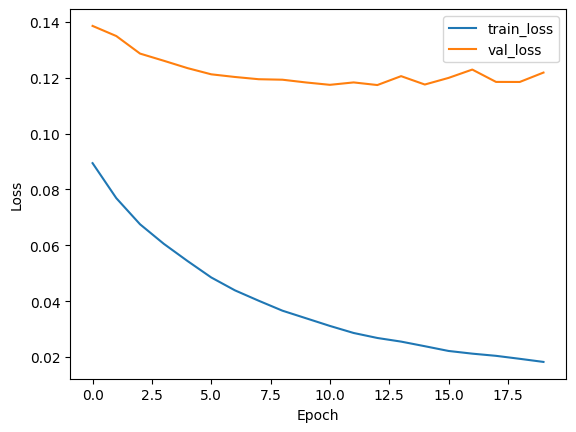

In [32]:
# Graficar pérdida
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## 4. Evaluación del Modelo

In [34]:

def generate_response_tf(model, source_text, max_len=MAX_LEN):
    """
    Genera un turno de respuesta dado un source_text usando greedy decoding.
    """
    # 1) Codificar entrada (one-hot) y expandir batch dimension
    enc_oh = encode_onehot(source_text)      # (MAX_LEN, vocab_size)
    enc_oh = tf.expand_dims(enc_oh, 0)       # (1, MAX_LEN, vocab_size)

    # 2) Inicializar decoder input IDs con BOS
    dec_ids = [bos_id]

    for step in range(max_len - 1):
        # Construir decoder input one-hot hasta la posición actual
        current_dec_ids = dec_ids + [pad_id] * (max_len - len(dec_ids))
        dec_oh = tf.one_hot([current_dec_ids], depth=vocab_size)  # (1, MAX_LEN, vocab_size)

        # Predecir logits
        logits = model([enc_oh, dec_oh], training=False)  # (1, MAX_LEN, vocab_size)

        # CORRECCIÓN: Tomar el token en la posición step (no len(dec_ids)-1)
        # porque dec_ids ya incluye BOS, entonces step corresponde a la siguiente posición
        next_logits = logits[0, step, :]  # (vocab_size,)

        # CORRECCIÓN: Opcional - aplicar máscara para evitar generar PAD, BOS
        # Penalizar fuertemente PAD y BOS
        mask = tf.ones_like(next_logits)
        mask = tf.tensor_scatter_nd_update(mask, [[pad_id]], [-1e9])
        mask = tf.tensor_scatter_nd_update(mask, [[bos_id]], [-1e9])
        next_logits = next_logits + mask

        next_id = int(tf.argmax(next_logits))

        dec_ids.append(next_id)
        if next_id == eos_id:
            break

    # Quitar BOS y EOS para la salida final
    output_ids = dec_ids[1:]  # Quitar BOS
    if output_ids and output_ids[-1] == eos_id:
        output_ids = output_ids[:-1]  # Quitar EOS

    # Convertir IDs a palabras, filtrando tokens especiales
    words = []
    for i in output_ids:
        if i < len(vocab) and vocab[i] not in ['<pad>', '<unk>', '<bos>', '<eos>']:
            words.append(vocab[i])

    return words

In [37]:
# Función alternativa usando sampling en lugar de greedy
def generate_response_sampling(model, source_text, temperature=0.8, max_len=MAX_LEN):
    """
    Generación usando sampling con temperatura para más diversidad
    """
    enc_oh = encode_onehot(source_text)
    enc_oh = tf.expand_dims(enc_oh, 0)

    dec_ids = [bos_id]

    for step in range(max_len - 1):
        current_dec_ids = dec_ids + [pad_id] * (max_len - len(dec_ids))
        dec_oh = tf.one_hot([current_dec_ids], depth=vocab_size)

        logits = model([enc_oh, dec_oh], training=False)
        next_logits = logits[0, step, :] / temperature

        # Aplicar máscara
        mask = tf.ones_like(next_logits)
        mask = tf.tensor_scatter_nd_update(mask, [[pad_id]], [-1e9])
        mask = tf.tensor_scatter_nd_update(mask, [[bos_id]], [-1e9])
        next_logits = next_logits + mask

        # Sampling en lugar de argmax
        next_id = tf.random.categorical([next_logits], 1)[0, 0]
        next_id = int(next_id)

        dec_ids.append(next_id)
        if next_id == eos_id:
            break

    output_ids = dec_ids[1:]
    if output_ids and output_ids[-1] == eos_id:
        output_ids = output_ids[:-1]

    words = []
    for i in output_ids:
        if i < len(vocab) and vocab[i] not in ['<pad>', '<unk>', '<bos>', '<eos>']:
            words.append(vocab[i])

    return words

In [35]:
# Función de diagnóstico para verificar el modelo
def diagnose_model_output(model, source_text, max_steps=5):
    """
    Función para diagnosticar qué está prediciendo el modelo paso a paso
    """
    print(f"Diagnosticando: '{source_text}'")

    enc_oh = encode_onehot(source_text)
    enc_oh = tf.expand_dims(enc_oh, 0)

    dec_ids = [bos_id]

    for step in range(max_steps):
        current_dec_ids = dec_ids + [pad_id] * (MAX_LEN - len(dec_ids))
        dec_oh = tf.one_hot([current_dec_ids], depth=vocab_size)

        logits = model([enc_oh, dec_oh], training=False)
        next_logits = logits[0, step, :]

        # Mostrar top 5 predicciones
        top_indices = tf.nn.top_k(next_logits, k=5).indices.numpy()
        top_probs = tf.nn.softmax(next_logits).numpy()

        print(f"Paso {step}:")
        for i, idx in enumerate(top_indices):
            word = vocab[idx] if idx < len(vocab) else f"ID_{idx}"
            prob = top_probs[idx]
            print(f"  {i+1}. {word} (prob: {prob:.4f})")

        next_id = int(tf.argmax(next_logits))
        dec_ids.append(next_id)

        if next_id == eos_id:
            break

    return dec_ids

In [38]:
# Primero, diagnostica qué está pasando
sample_inp = train_inputs[0]
diagnose_model_output(transformer, sample_inp)

# Luego prueba la generación corregida
print("Generación corregida:", " ".join(generate_response_tf(transformer, sample_inp)))

# O prueba con sampling
print("Generación con sampling:", " ".join(generate_response_sampling(transformer, sample_inp)))

Diagnosticando: 'Say , Jim , how about going for a few beers after dinner ?'
Paso 0:
  1. <pad> (prob: 0.9746)
  2. barbie's (prob: 0.0026)
  3. 3land (prob: 0.0026)
  4. catholics (prob: 0.0018)
  5. am.you (prob: 0.0016)
Paso 1:
  1. <pad> (prob: 0.9960)
  2. catholics (prob: 0.0003)
  3. # (prob: 0.0003)
  4. beers (prob: 0.0003)
  5. beneficial (prob: 0.0003)
Paso 2:
  1. <pad> (prob: 0.9969)
  2. catholics (prob: 0.0004)
  3. beers (prob: 0.0002)
  4. beneficial (prob: 0.0002)
  5. 3.60 (prob: 0.0002)
Paso 3:
  1. <pad> (prob: 0.9966)
  2. catholics (prob: 0.0005)
  3. beneficial (prob: 0.0002)
  4. beers (prob: 0.0002)
  5. 3.60 (prob: 0.0002)
Paso 4:
  1. <pad> (prob: 0.9952)
  2. catholics (prob: 0.0004)
  3. 3land (prob: 0.0003)
  4. 14 (prob: 0.0003)
  5. # (prob: 0.0003)
Generación corregida: barbie's # catholics # 3land # catholics # catholics # catholics # catholics # catholics # barbie's # barbie's # # # # catholics # catholics # catholics # barbie's # catholics catholics

## 5. Ajuste de Hiperparámetros

In [ ]:

# Probar diferentes configuraciones de hiperparámetros
# Ejemplo: modificar num_heads, ff_dim, número de capas

# Documentar los resultados y evaluar cada configuración
# for num_heads in [2, 4, 8]:
#     for ff_dim in [32, 64, 128]:
#         # Redefinir y entrenar modelo con nuevos hiperparámetros
#         # Registrar métricas y comparar rendimiento


## 6. Presentación de Resultados y Conclusiones


En esta sección, resumiremos los resultados obtenidos, mostrando cómo los ajustes de los hiperparámetros impactaron en el rendimiento del modelo.
- **Resultados Finales**: Comparación de BLEU, ROUGE, y otras métricas para cada configuración.
- **Conclusiones**: Reflexión sobre el proceso, dificultades encontradas y aprendizajes obtenidos.

¡Gracias por revisar nuestro proyecto! Esperamos que esta implementación demuestre nuestro dominio en el uso de transformers para NLP.
